<a href="https://colab.research.google.com/github/nladocsi/DS3001_F25_Project/blob/main/Milestone3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Milestone 3
## Setting Up and Uploading Data

In [9]:
import numpy as np
import pandas as pd
from sklearn import tree
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('./adult24.csv')
print(df.shape, '\n')
df.head()

/tmp/ipython-input-4259426878.py:1: DtypeWarning: Columns (546,547) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('./adult24.csv')


(33673, 630) 



,RATCAT_A,INCTCFLG_A,IMPINCFLG_A,PPSU,PSTRAT,WLKLEISTC_A,WLKTRANTC_A,HISPALLP_A,RACEALLP_A,ANYDIFF_A,...,LSATIS4_A,PHSTAT_A,HHSTAT_A,INTV_MON,RECTYPE,IMPNUM_A,AVGNUMCIG_A,WTFA_A,HHX,POVRATTC_A
0,9,0,2,2,122,NaN,NaN,2,1,2,...,1.0,1.0,1.0,1.0,10.0,1.0,30,5780.565,H067658,2.82
1,8,0,0,2,122,20.0,NaN,2,1,2,...,2.0,2.0,1.0,1.0,10.0,1.0,20,3994.244,H076577,2.01
2,7,0,0,2,122,30.0,NaN,2,1,1,...,1.0,2.0,1.0,1.0,10.0,1.0,20,6636.755,H019335,1.90
3,12,0,0,2,122,10.0,NaN,2,1,1,...,2.0,3.0,1.0,1.0,10.0,1.0,01,13767.420,H012701,4.48
4,14,0,0,1,115,NaN,NaN,3,2,1,...,2.0,3.0,1.0,1.0,10.0,1.0,NaN,18880.030,H049678,6.37


## Cleaning Data

In [4]:
#Keeping Only Columns of Interest
cols = ['GESDIB_A', 'PREDIB_A', 'DIBEV_A', 'DIBTYPE_A',
        'DIBAGETC_A', 'FDSRUNOUT_A', 'FDSLAST_A',
        'FDSHUNGRY_A','FSNAP12M_A', 'FSNAP30D_A', 'SEX_A', 'REGION', 'RACEALLP_A',
        'RATCAT_A', 'EDUCP_A', 'PHSTAT_A', 'WLKLEIS_A', 'BMICAT_A', 'HYPEV_A','CHLEV_A','AGEP_A']
df = df[cols]
print(df.shape, '\n')
df.head()

(33673, 21) 



,GESDIB_A,PREDIB_A,DIBEV_A,DIBTYPE_A,DIBAGETC_A,FDSRUNOUT_A,FDSLAST_A,FDSHUNGRY_A,FSNAP12M_A,FSNAP30D_A,...,REGION,RACEALLP_A,RATCAT_A,EDUCP_A,PHSTAT_A,WLKLEIS_A,BMICAT_A,HYPEV_A,CHLEV_A,AGEP_A
0,NaN,2.0,2.0,NaN,NaN,3.0,3,NaN,2.0,NaN,...,3,1,9,5,1.0,2.0,3,2.0,2.0,49.0
1,NaN,2.0,2.0,NaN,NaN,3.0,3,NaN,2.0,NaN,...,3,1,8,5,2.0,1.0,3,1.0,2.0,53.0
2,NaN,2.0,2.0,NaN,NaN,3.0,3,NaN,2.0,NaN,...,3,1,7,5,2.0,1.0,4,1.0,2.0,82.0
3,NaN,2.0,2.0,NaN,NaN,3.0,2,2.0,2.0,NaN,...,3,1,12,4,3.0,1.0,3,2.0,2.0,42.0
4,2.0,2.0,2.0,NaN,NaN,3.0,3,NaN,2.0,NaN,...,3,2,14,9,3.0,2.0,3,2.0,2.0,38.0


In [5]:
#Creating Food Insecurity Variable
df[["FSNAP12M_A", "FSNAP30D_A", "FDSRUNOUT_A","FDSLAST_A", "FDSHUNGRY_A"]] = df[["FSNAP12M_A", "FSNAP30D_A", "FDSRUNOUT_A", "FDSLAST_A", "FDSHUNGRY_A"]].replace([7, 8, 9], np.nan)

df["FOOD_INS"] = np.where((df[["FSNAP12M_A", "FSNAP30D_A", "FDSRUNOUT_A", "FDSLAST_A", "FDSHUNGRY_A"]] == 1).any(axis=1), 1,
    np.where((df[["FDSRUNOUT_A","FDSLAST_A"]] == 2).any(axis=1), 1,
             np.where((df[["FSNAP12M_A", "FSNAP30D_A", "FDSHUNGRY_A"]] == 2).any(axis=1),0,
                      np.where((df[["FSNAP12M_A", "FSNAP30D_A"]] == 3).any(axis=1),0, np.nan))))
df = df.drop(columns=["FSNAP12M_A", "FSNAP30D_A", "FDSRUNOUT_A","FDSLAST_A", "FDSHUNGRY_A"])
df.head()



,GESDIB_A,PREDIB_A,DIBEV_A,DIBTYPE_A,DIBAGETC_A,SEX_A,REGION,RACEALLP_A,RATCAT_A,EDUCP_A,PHSTAT_A,WLKLEIS_A,BMICAT_A,HYPEV_A,CHLEV_A,AGEP_A,FOOD_INS
0,NaN,2.0,2.0,NaN,NaN,1.0,3,1,9,5,1.0,2.0,3,2.0,2.0,49.0,0.0
1,NaN,2.0,2.0,NaN,NaN,1.0,3,1,8,5,2.0,1.0,3,1.0,2.0,53.0,0.0
2,NaN,2.0,2.0,NaN,NaN,1.0,3,1,7,5,2.0,1.0,4,1.0,2.0,82.0,0.0
3,NaN,2.0,2.0,NaN,NaN,1.0,3,1,12,4,3.0,1.0,3,2.0,2.0,42.0,1.0
4,2.0,2.0,2.0,NaN,NaN,2.0,3,2,14,9,3.0,2.0,3,2.0,2.0,38.0,0.0


In [6]:
#Creating one variable for diabetes
df[["PREDIB_A", "GESDIB_A", "DIBEV_A"]] = df[["PREDIB_A", "GESDIB_A", "DIBEV_A"]].replace([7, 8, 9], np.nan)

df["DIAB_ANY"] = np.where((df[["PREDIB_A", "GESDIB_A", "DIBEV_A"]] == 1).any(axis=1), 1,
    np.where((df[["PREDIB_A", "GESDIB_A", "DIBEV_A"]] == 2).any(axis=1), 0, np.nan))
df = df.drop(columns=["PREDIB_A", "GESDIB_A", "DIBEV_A"])

df.head()

,DIBTYPE_A,DIBAGETC_A,SEX_A,REGION,RACEALLP_A,RATCAT_A,EDUCP_A,PHSTAT_A,WLKLEIS_A,BMICAT_A,HYPEV_A,CHLEV_A,AGEP_A,FOOD_INS,DIAB_ANY
0,NaN,NaN,1.0,3,1,9,5,1.0,2.0,3,2.0,2.0,49.0,0.0,0.0
1,NaN,NaN,1.0,3,1,8,5,2.0,1.0,3,1.0,2.0,53.0,0.0,0.0
2,NaN,NaN,1.0,3,1,7,5,2.0,1.0,4,1.0,2.0,82.0,0.0,0.0
3,NaN,NaN,1.0,3,1,12,4,3.0,1.0,3,2.0,2.0,42.0,1.0,0.0
4,NaN,NaN,2.0,3,2,14,9,3.0,2.0,3,2.0,2.0,38.0,0.0,0.0


In [22]:
#Final code to run at end of data manipulation

df.to_csv('diabetes_clean.csv', index=False)

## Visualizing the data


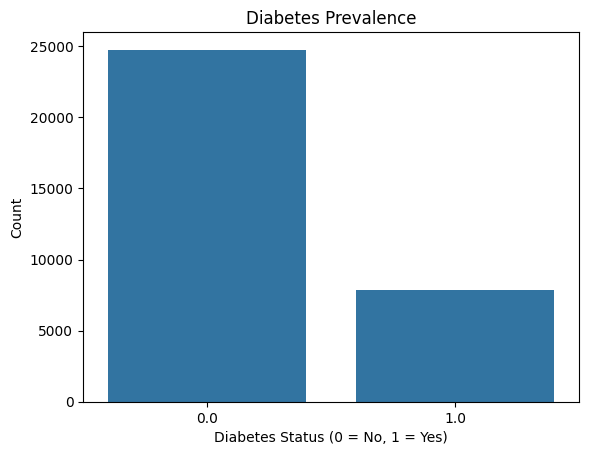

In [ ]:
sns.countplot(data=df, x="DIAB_ANY")
plt.title("Diabetes Prevalence")
plt.xlabel("Diabetes Status (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

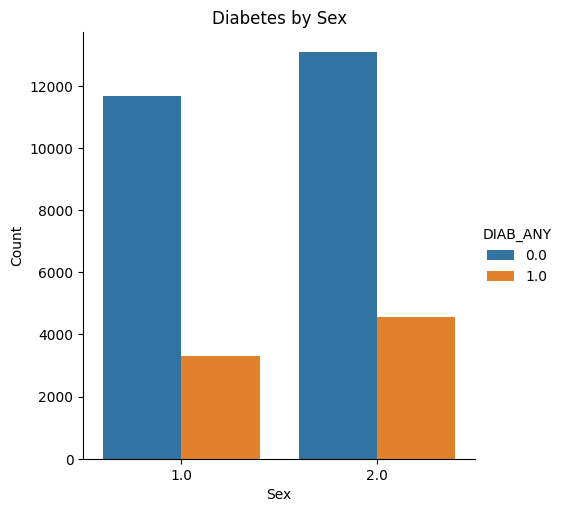

In [ ]:
df[["SEX_A"]] = df[["SEX_A"]].replace([7, 8, 9], np.nan)

sns.catplot(
    data=df,
    x="SEX_A",
    hue="DIAB_ANY",
    kind="count"
)
plt.title("Diabetes by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

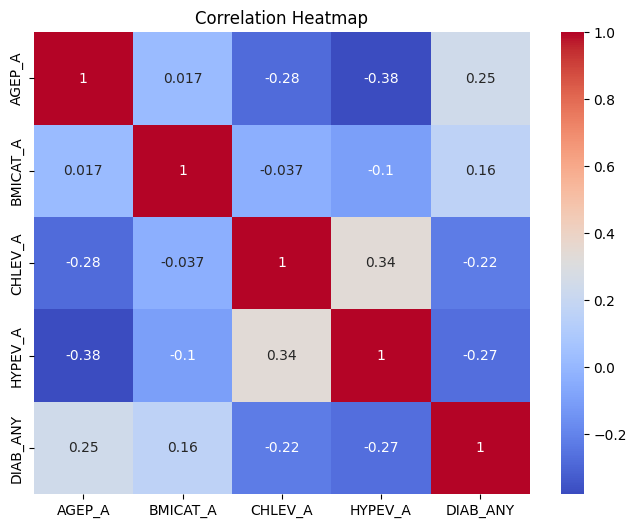

In [ ]:
plt.figure(figsize=(8,6))
corr = df[['AGEP_A','BMICAT_A','CHLEV_A','HYPEV_A','DIAB_ANY']].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Building Model
### Setting up Tree

In [17]:
df.shape
df['DIAB_ANY'].value_counts()
min_samples_leaf = max(1, int(0.01 * len(X_train)))
print(min_samples_leaf)

NameError: name 'X_train' is not defined

In [23]:
from sklearn.model_selection import train_test_split

df = df.dropna(subset=['DIAB_ANY'])
df_train = df.iloc[:int(.8*df.shape[0]),:]
df_test = df.iloc[int(.8*df.shape[0]):,:]
y_test = df_test['DIAB_ANY']
X_test = df_test.drop('DIAB_ANY',axis=1)

min_samp = max(1, int(0.01 * len(df_train)))

def quick_tree(df,depth=15):
    # Resample and Process data:
    df_t = df_train.sample(n=df.shape[0],replace=True)
    y_train = df_t['DIAB_ANY']
    X_train = df_t.drop('DIAB_ANY',axis=1)
    # Fit decision tree:
    cart = tree.DecisionTreeRegressor(max_depth=depth, min_samples_leaf=min_samp) #200 chosen because of number of data points
    cart = cart.fit(X_train, y_train)
    # Visualize results:
    plt.figure(figsize=(10,10))
    tree.plot_tree(cart,feature_names=X_train.columns.to_list(),filled=True)
    plt.show()
    # Rsq:
    y_hat = cart.predict(X_test)
    SSE = np.sum( (y_test-y_hat)**2 )
    TSS = np.sum( (y_test-y_train.mean())**2 )
    Rsq = 1 - SSE/TSS
    print("R^2:", Rsq)
    return y_hat

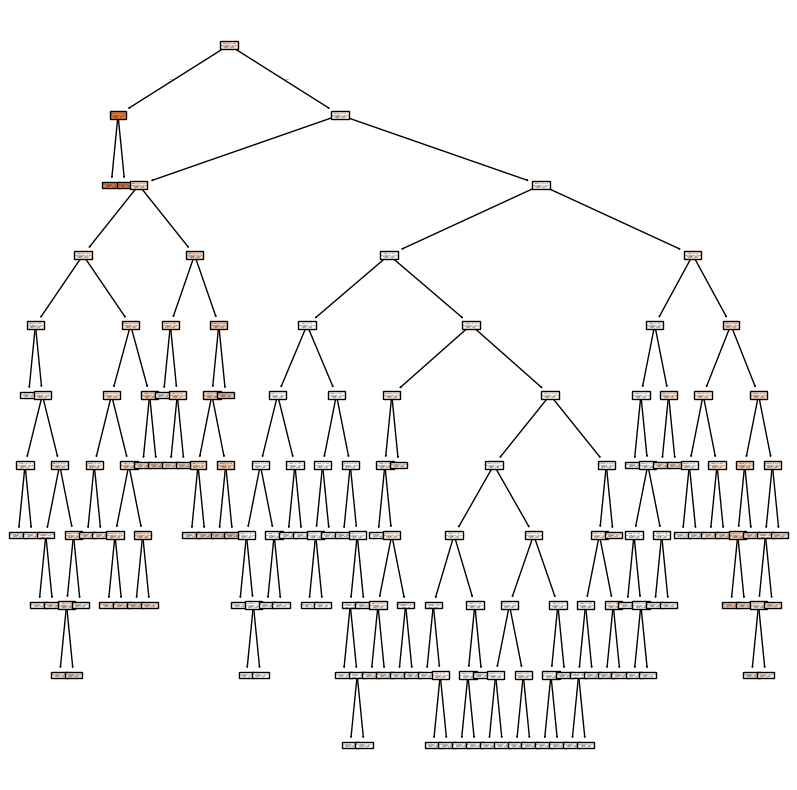

R^2: 0.459630589110011


In [24]:
y_hat_1 = quick_tree(df)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

df = pd.read_csv('diabetes_clean.csv')
df.head()

,DIBTYPE_A,DIBAGETC_A,SEX_A,REGION,RACEALLP_A,RATCAT_A,EDUCP_A,PHSTAT_A,WLKLEIS_A,BMICAT_A,HYPEV_A,CHLEV_A,AGEP_A,FOOD_INS,DIAB_ANY
0,NaN,NaN,1,3,1,9,5,1,2.0,3,2,2,49,0.0,0.0
1,NaN,NaN,1,3,1,8,5,2,1.0,3,1,2,53,0.0,0.0
2,NaN,NaN,1,3,1,7,5,2,1.0,4,1,2,82,0.0,0.0
3,NaN,NaN,1,3,1,12,4,3,1.0,3,2,2,42,1.0,0.0
4,NaN,NaN,2,3,2,14,9,3,2.0,3,2,2,38,0.0,0.0


In [ ]:
X = df
y = df['DIAB_ANY']

In [ ]:
clean = pd.concat([X, y], axis =1)
clean = clean.dropna()

X = clean.drop(columns='DIAB_ANY')
y = clean['DIAB_ANY']

X = pd.get_dummies(X, drop_first = True)

In [ ]:
X = pd.get_dummies(X, drop_first = True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =42)

### Determining Optimal Leaf Value

In [ ]:
from sklearn.tree import DecisionTreeClassifier

scores = []
leaf_value = range(1, 150, 5)

for l in leaf_value:
  cart = DecisionTreeClassifier(min_samples_leaf =l)
  cart = cart.fit(X_train, y_train)
  scores.append(cart.score(X_test, y_test))

In [ ]:
best_score = max(scores)
best_leaf = list(leaf_value)[scores.index(best_score)]
print('Best R2: ', best_score)
print('Best Leaf Value: ', best_leaf)

Best R2:  1.0
Best Leaf Value:  1


### Building Tree

In [ ]:
#FILL IN WITH IMPROVED LEAF SIZE
tree = DecisionTreeClassifier(min_samples_leaf=10)
tree.fit(X_train, y_train)

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 10))
plot_tree(tree, filled = True)
plt.title('Decision Tree')
plt.show()

In [ ]:
y_hat = tree.predict(X_test)
SSE = np.sum((y_test - y_hat)**2)
TSS = np.sum((y_test - np.mean(y_test))**2)
Rsq = 1 - (SSE/TSS)
print('R^2: ', Rsq)

### Evaluating Accuracy

In [ ]:
y_hat = tree.predict(X_test)

tab = pd.crosstab(y_test, y_hat)
acc = np.trace(tab)/len(y_test)
print('Accuracy: ', round(acc,3), '\n')
print(tab)

In [ ]:
TP = tab.iloc[0,0]
TN = tab.iloc[1,1]
FP = tab.iloc[1,0]
FN = tab.iloc[0,1]

TPR = TP/(TP+FN)
TNR = TN/(TN+FP)

print('True Positive Rate: ', round(TPR, 3))
print('True Negative Rate: ', round(TNR, 3))

In [ ]:
plt.scatter(y_test, y_hat)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs. Predicted Values')
plt.plot

### Bootstrapping

In [ ]:
N = df.shape[0]
df = df.sample(frac=1, random_state=100)
train_size=int(.8*N)
df_train = df.iloc[:train_size,:]
df_test = df.iloc[train_size:,:]
N_train = df_train.shape[0]
N_test = df_test.shape[0]
df_train.head()

In [ ]:
T = 1000
m_depth =10
Rsq = np.zeros(T)
y_test_hat = np.zeros(T, N_test)

X_train = df_train.drop(columns='DIAB_ANY', axis=1)
y_train = np.arcsinh(df_train['DIAB_ANY'])
X_test = df_test.drop(columns='DIAB_ANY', axis=1)
y_test = np.arcsinh(df_test['DIAB_ANY'])

for s in range(T):
  df_s = df_train.sample(frac=1, replace=True)
  X_s = df_s.drop(columns='DIAB_ANY', axis=1)
  y_s = np.arcsinh(df_s['DIAB_ANY'])

  cart = tree.DecisionTreeRegressor(max_depth=m_depth)
  cart = cart.fit(X_s, y_s)

  y_hat = cart.predict(X_test)
  SSE = np.sum((y_test - y_hat)**2)
  TSS = np.sum((y_test - y_s.mean())**2)
  Rsq[s] = 1 - (SSE/TSS)
  y_test_hat[s,:] = y_hat

y_hat_ensemble = y_test_hat.mean(axis=0)
SSE = np.sum((y_test - y_hat_ensemble)**2)
TSS = np.sum((y_test -y_train.mean())**2)
Rsq_ensemble = 1 - (SSE/TSS)
print('R^2: ', Rsq_ensemble)

### Random Forests

In [ ]:
y_train.head()

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(max_depth=10)
rf = model.fit(X_train, y_train)

y_hat_rf = rf.predict(X_test)

In [ ]:
sns.scatterplot(y=y_test, x=y_hat_rf, alpha-.25).set(title='Random Forest vs Test', xlabel='Test', ylabel='RF')